# 24RB1003 松澤颯斗

# 演習：正則化の効果を比較する

## 設定

In [9]:
# サンプル数を100，特徴量数を30，有効次元を5に設定してデータを生成
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=30, n_informative=5, random_state=0)

# データの形状を確認
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 30)
y shape: (100,)


In [10]:
# データを訓練用とテスト用に分割
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#  訓練用データとテスト用データの形状を確認
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (80, 30)
X_test shape: (20, 30)


In [11]:
# 特徴量を標準化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 課題１：$\lambda$（`alpha`）を変える

In [12]:
# Ridge回帰とLasso回帰の学習と評価
import numpy as np
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 2, 6)  # αの値を10^-3から10^2までの対数スケールで生成
ridge_mse_train = []
ridge_mse_test = []
lasso_mse_train = []
lasso_mse_test = []

for alpha in alphas:
    # Ridge回帰の学習と評価
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_mse_train.append(np.mean((ridge.predict(X_train_scaled) - y_train) ** 2))
    ridge_mse_test.append(np.mean((ridge.predict(X_test_scaled) - y_test) ** 2))
    
    # Lasso回帰の学習と評価
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_mse_train.append(np.mean((lasso.predict(X_train_scaled) - y_train) ** 2))
    lasso_mse_test.append(np.mean((lasso.predict(X_test_scaled) - y_test) ** 2))

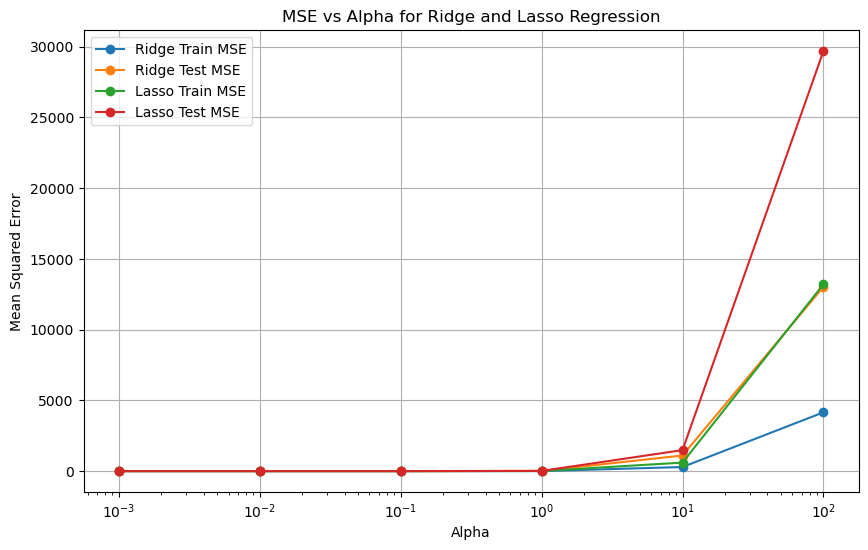

In [13]:
# 訓練MSEとテストMSEをプロット
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_mse_train, label='Ridge Train MSE', marker='o')
plt.plot(alphas, ridge_mse_test, label='Ridge Test MSE', marker='o')
plt.plot(alphas, lasso_mse_train, label='Lasso Train MSE', marker='o')
plt.plot(alphas, lasso_mse_test, label='Lasso Test MSE', marker='o')
plt.xscale('log')   
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Alpha for Ridge and Lasso Regression')
plt.legend()
plt.grid()
plt.show()

#### 観察メモ

* $\alpha$ が小さい領域（$10^{-3} \sim 10^0$）  
Ridge回帰およびLasso回帰ともに，訓練MSEとテストMSEは低い値で安定している．これは正則化の罰則が弱く，モデルがデータに対して十分に適合できている状態である．

* $\alpha$ が大きい領域（$10^1 \sim 10^2$）  
両手法ともに訓練MSEおよびテストMSEが急激に悪化している．特にLasso回帰の誤差の増加が著しい．

* 考察  
正則化パラメータ $\alpha$ を大きくすることで，仮説集合が強く制限されたためである．結果として推定誤差は下がるものの，近似誤差が増大し，モデルがデータの特徴を表現しきれない過少適合の状態に陥っていると考えられる．

# 課題２：$L_2$ と $L_1$ の係数を比較

In [14]:
# alpha=1でRidgeとLassoを学習
ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)
lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [15]:
# 係数ベクトルを表示
print("Ridge coefficients:", ridge.coef_)
print("Lasso coefficients:", lasso.coef_)

Ridge coefficients: [-3.99027376e-01 -2.07298474e-01  4.87730644e+01  3.72508561e-01
  3.21800816e-01  3.53893059e+01  9.45086998e-02  7.81818842e-02
  1.37561326e-01  4.03217813e-01  3.30221527e-01  4.02679883e-02
 -1.99125243e-01 -4.50008094e-01 -9.45724171e-02  1.38603101e-01
  7.79675213e+01  6.93232889e+01  3.12371669e+01 -2.70146433e-01
  1.89624372e-01  7.80340121e-02  2.04955816e-01  2.60601898e-01
  5.30228806e-02 -3.24843980e-01 -4.91895088e-01  1.37639783e-01
  9.23555869e-02  4.28694551e-01]
Lasso coefficients: [-0.         -0.         48.74933534  0.          0.         35.06213371
  0.          0.          0.          0.          0.         -0.
 -0.         -0.         -0.          0.         78.44615322 69.62230519
 30.83301624 -0.          0.          0.          0.          0.
  0.         -0.         -0.          0.          0.          0.        ]


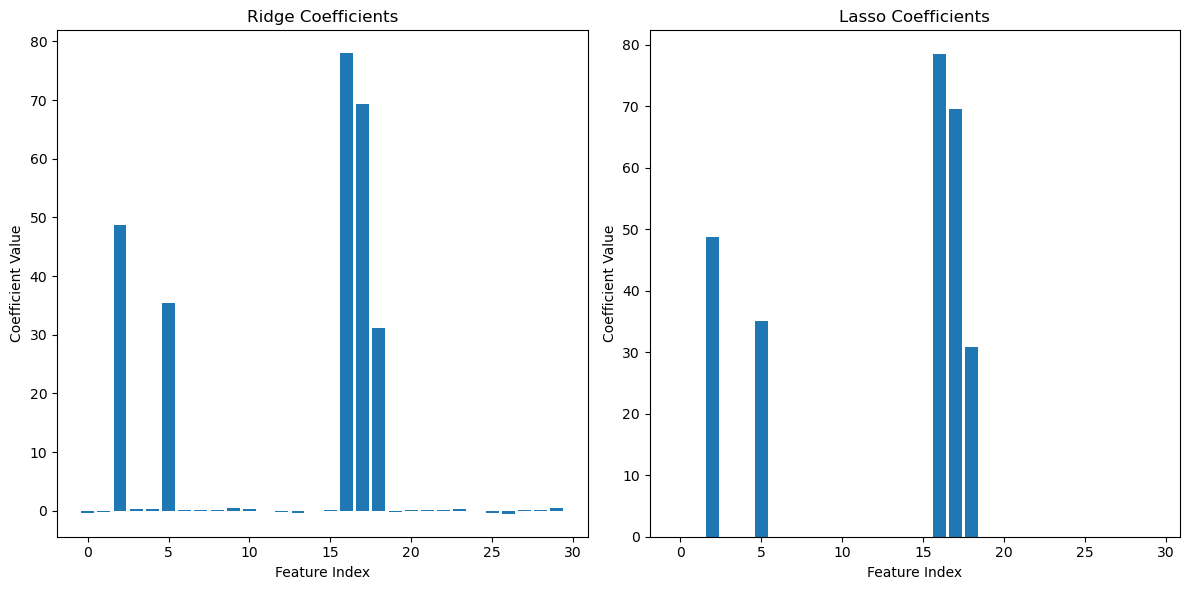

In [16]:
# 係数ベクトルを棒グラフで可視化
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(len(ridge.coef_)), ridge.coef_)
plt.title('Ridge Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.subplot(1, 2, 2)
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.title('Lasso Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()


#### 観察メモ

* Ridge回帰（$L_2$正則化）の傾向  
影響の小さい特徴量の係数も完全には0にはならず，0に近い小さな値として残る．重みベクトル全体を均一に0に近づけるように縮める性質が確認できる．

* Lasso回帰（$L_1$正則化）の傾向  
設定した有効な次元（`n_informative=5`）に対応する5つの特徴量以外の係数が，完全に0になる．不要な特徴量を削ぎ落とし，モデルをスパース（疎）にする性質が確認できる．

* 考察  
Lasso回帰は自動的な特徴量選択の機能を持つため，重要な変数が限られている場合に有効である．一方で，Ridge回帰はすべての特徴量を少しずつ考慮するため，全体的にノイズを抑えながら予測を行いたい場合に適していると考えられる．

# 考察

正則化パラメータ$\alpha$を過剰に大きくすると近似誤差が増大し，モデルがデータの特徴を捉えきれない過少適合を引き起こす．そのため，最適な汎化性能を得るには適切なパラメータ調整が不可欠である．また手法ごとの性質として，不要な特徴量の係数を完全に0にするLasso回帰は特徴量選択に有効に働く．一方で，すべての係数を小さく縮めつつ残すRidge回帰は，多数の変数が少しずつ影響するデータに適している．結論として，データの特徴に応じて最適な手法を選択し，正則化の強度を適切に調整することが重要であると考えられる．

# AI使用について

Gemini Guided Learningを使用して，`ridge`や`lasso`の実装方法について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．